<a href="https://colab.research.google.com/github/abeerahb/basic-workshop-/blob/main/Part_2___Intro_to_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###_B9 Network Neuroscience and AI : Python, Machine Learning and AI Workshop_

#Part 2: Introduction to Machine Learning

In this part we will learn how to train and test two different ML models on the MNIST handwritten digit dataset using the sklearn library.

In [3]:
# First import numerical and plotting libraries
import numpy as np
import matplotlib.pyplot as plt

## MNIST dataset

The MNIST dataset is a collection of handwritten digit images used extensively in machine learning for training and benchmarking image classification algorithms, particularly neural networks.

In [4]:
# Next lets import the dataset we want to work with
# Today we'll use a smaller version of the MNIST dataset just to practice with (less images, 8x8 instead of 28x28)
from sklearn.datasets import load_digits
digits = load_digits()

In [5]:
digits.data.shape

(1797, 64)

In [6]:
digits.data[0].shape

(64,)

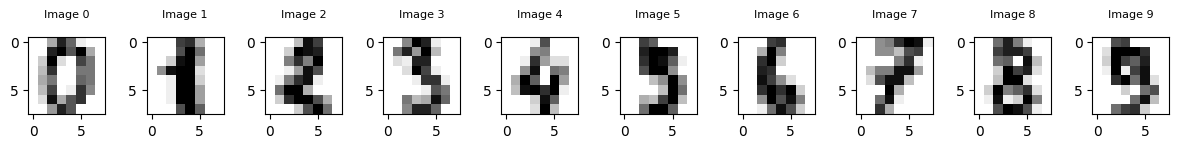

In [7]:
# Plotting the image data
# Note: The digits.data is a 64-element linear array representing an 8x8 image.
# We need to reshape it to (8,8) for correct visualization.
plt.figure(figsize=(15,1))
for index, (image, label) in enumerate(zip(digits.data[0:10],
                                           digits.target[0:10])):
    plt.subplot(1, 10, index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.binary)
    plt.title('Image %i\n' % label, fontsize = 8);

## Train-test split

In machine learning, a train-test split separates data into training and testing sets. We train the model on the training set and evaluate the model's performance on the unseen test data, preventing overfitting and providing an unbiased assessment of the model's generalization ability.

In [8]:
# Split the data into train and test sets
# We'll set the percentage of images in the test set using the test_size argument.
# `train_test_split` returns four arrays: X_train, X_test, y_train, y_test.
# X_train: features for training, X_test: features for testing.
# y_train: labels for training, y_test: labels for testing.
# `test_size=0.25`: Allocates 25% of the data to the test set and 75% for training.
# `random_state=0`: Ensures reproducibility; running the code multiple times with this will produce the same split.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data,
                                                    digits.target,
                                                   test_size=0.25,
                                                   random_state=0)

In [9]:
X_train.shape

(1347, 64)

In [10]:
X_test.shape

(450, 64)

##Logistic regression

Logistic regression is a statistical method for multi-class classification that predicts the probability of an instance belonging to a particular class by transforming a linear combination of features using the sigmoid function.

See sklearn documentation at:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html



In [11]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(fit_intercept=True, penalty='l2', max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# Score on the training set
logreg_train_score = clf.score(X_train, y_train)
print(logreg_train_score)

1.0


In [13]:
print("Logistic Regression Coefficients (clf.coef_):\n", clf.coef_)
print("\nLogistic Regression Intercept (clf.intercept_):\n", clf.intercept_)
print("\nLogistic Regression Classes (clf.classes_):\n", clf.classes_)

Logistic Regression Coefficients (clf.coef_):
 [[ 0.00000000e+00 -2.78233457e-03 -3.25876253e-02  7.37969225e-02
   6.53273186e-02 -1.07239579e-01 -1.32369787e-01 -1.58562822e-02
  -5.25678593e-05 -3.11048405e-02 -4.53293379e-02  1.69095460e-01
   7.04831440e-02  7.14073202e-02 -4.29936545e-02 -1.19755096e-02
  -1.03857319e-05  5.06577831e-02  1.00577102e-01 -1.67952221e-02
  -3.17434389e-01  1.93865358e-01  7.72634521e-02 -2.03870932e-03
  -5.08494140e-06  1.02153358e-01  1.12377023e-01 -1.23850697e-01
  -4.40222636e-01 -1.01048092e-03  9.39179378e-02 -1.13578810e-04
   0.00000000e+00  1.31495289e-01  7.23144845e-02 -1.20821223e-01
  -3.33360668e-01  3.80207131e-02  5.78356499e-02  0.00000000e+00
  -2.60992939e-04 -6.17007171e-02  2.31662949e-01 -8.26170978e-02
  -1.65936306e-01  1.29597683e-01  2.71449174e-02 -2.16029282e-04
  -8.51826696e-04 -9.29714458e-02  6.95452526e-02 -4.58773471e-02
   1.74039105e-01  7.61347543e-02 -2.20959549e-02 -8.77328003e-03
  -6.19476503e-06 -8.18702457

In [14]:
logreg_test_score = clf.score(X_test, y_test) # test score
print(logreg_test_score)

0.9533333333333334


##Neural network
Let's compare the performance of logistic regression classification with a multi-layer fully connected neural network...

https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [15]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=[512, 256, 128],  # Two hidden layers
    max_iter=1000,
    verbose=True
)
mlp.fit(X_train, y_train)

Iteration 1, loss = 1.88245159
Iteration 2, loss = 0.41143866
Iteration 3, loss = 0.17443940
Iteration 4, loss = 0.10323221
Iteration 5, loss = 0.06625581
Iteration 6, loss = 0.04265235
Iteration 7, loss = 0.02689955
Iteration 8, loss = 0.01957911
Iteration 9, loss = 0.01456191
Iteration 10, loss = 0.01091915
Iteration 11, loss = 0.00881331
Iteration 12, loss = 0.00647118
Iteration 13, loss = 0.00548767
Iteration 14, loss = 0.00461880
Iteration 15, loss = 0.00371224
Iteration 16, loss = 0.00330135
Iteration 17, loss = 0.00289744
Iteration 18, loss = 0.00248312
Iteration 19, loss = 0.00226269
Iteration 20, loss = 0.00201398
Iteration 21, loss = 0.00180853
Iteration 22, loss = 0.00165676
Iteration 23, loss = 0.00152766
Iteration 24, loss = 0.00142008
Iteration 25, loss = 0.00131075
Iteration 26, loss = 0.00120123
Iteration 27, loss = 0.00112519
Iteration 28, loss = 0.00104876
Iteration 29, loss = 0.00098703
Iteration 30, loss = 0.00092800
Iteration 31, loss = 0.00086541
Iteration 32, los

MLPClassifier(hidden_layer_sizes=[512, 256, 128], max_iter=1000, verbose=True)

In [16]:
mlp_test_score = mlp.score(X_test, y_test) # test score
print(mlp_test_score)

0.9822222222222222


##Exercise 1

Can you improve the test score of your neural network by changing the numbers of neurons and hidden layers?

Look at the MLP documentation and see how changing the keyword arguments (kwarg) "solver", "activation" and "learning_rate" affect the test score.

##Exercise 2

In [17]:
# How do these models perform when using the full MNIST dataset (the one with 28x28 pixel images)?
# Use the following code to download the full dataset...
from sklearn.datasets import fetch_openml
mnist_full = fetch_openml('mnist_784', version=1, as_frame=False)

# Note: the training will take much longer with this larger dataset so this is something to explore in your own time